In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

In [5]:
data=pd.read_csv(r"D:\BACKEDUPDOC\STUDY\CSM\ROAD_ACCIDENT_PROJECT1\road_accident.csv")
data.head()

,accident_index,accident_date,day_of_week,junction_control,junction_detail,accident_severity,light_conditions,local_authority,carriageway_hazards,number_of_casualties,number_of_vehicles,police_force,road_surface_conditions,road_type,speed_limit,time,urban_or_rural_area,weather_conditions,vehicle_type
0,BS0000001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,Daylight,Kensington and Chelsea,NaN,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,BS0000002,05-01-2021,Monday,Give way or uncontrolled,Crossroads,Serious,Daylight,Kensington and Chelsea,NaN,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,04-01-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,Daylight,Kensington and Chelsea,NaN,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,05-01-2021,Monday,Auto traffic signal,T or staggered junction,Serious,Daylight,Kensington and Chelsea,NaN,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,08:10,Urban,Other,Motorcycle over 500cc
4,BS0000005,06-01-2021,Tuesday,Auto traffic signal,Crossroads,Serious,Darkness - lights lit,Kensington and Chelsea,NaN,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [7]:
data['accident_date'] = pd.to_datetime(data['accident_date'], format='%d-%m-%Y')
data['month'] = data['accident_date'].dt.month
data['year'] = data['accident_date'].dt.year

In [10]:
data = data[['month', 'year', 'day_of_week', 'light_conditions',
             'road_surface_conditions', 'weather_conditions',
             'urban_or_rural_area', 'vehicle_type',
             'number_of_casualties']].copy()

In [11]:
le = LabelEncoder()

for col in ['day_of_week', 'light_conditions', 'road_surface_conditions',
            'weather_conditions', 'urban_or_rural_area', 'vehicle_type']:
    data[col] = le.fit_transform(data[col])

In [13]:
X=data.drop('number_of_casualties',axis=1)
Y=data['number_of_casualties']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred = model.predict(X_test)

print("Model Error (MAE):", mean_absolute_error(y_test, y_pred))

Model Error (MAE): 0.5339964452127144


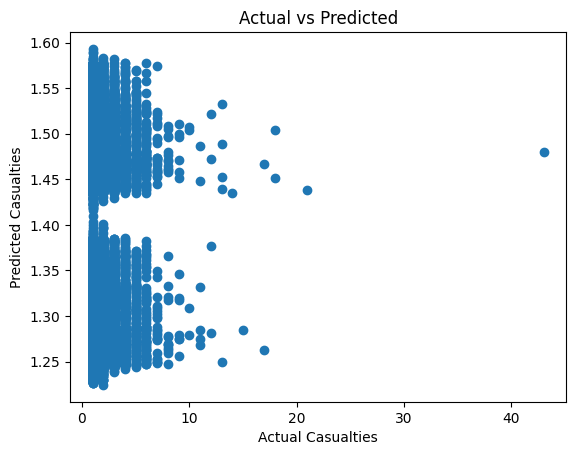

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Casualties")
plt.ylabel("Predicted Casualties")
plt.title("Actual vs Predicted")
plt.show()

In [20]:
future = pd.DataFrame({
    'month': [12],
    'year': [2025],
    'day_of_week': [1],
    'light_conditions': [1],
    'road_surface_conditions': [1],
    'weather_conditions': [1],
    'urban_or_rural_area': [1],
    'vehicle_type': [1]
})

print("Future Prediction:", model.predict(future))

Future Prediction: [1.34873547]


In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
data['risk_level'] = kmeans.fit_predict(X)


In [24]:
data[['month', 'year', 'number_of_casualties', 'risk_level']].head(10)

,month,year,number_of_casualties,risk_level
0,1,2021,1,0
1,1,2021,11,2
2,1,2021,1,2
3,1,2021,1,2
4,1,2021,1,0
5,1,2021,3,0
6,1,2021,1,2
7,1,2021,1,0
8,1,2021,2,2
9,1,2021,1,0


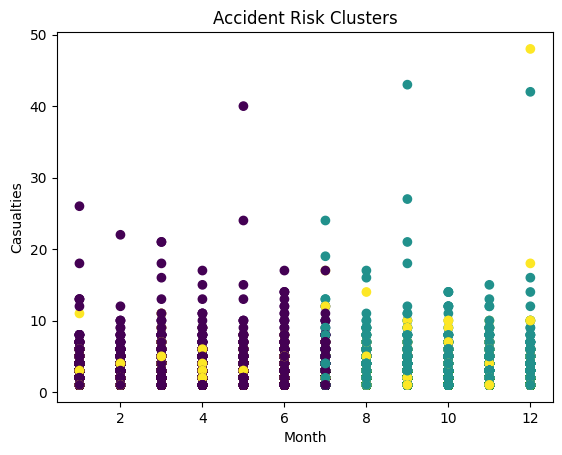

In [25]:
import matplotlib.pyplot as plt

plt.scatter(data['month'], data['number_of_casualties'], c=data['risk_level'])
plt.xlabel("Month")
plt.ylabel("Casualties")
plt.title("Accident Risk Clusters")
plt.show()

In [26]:
data['risk_level'].value_counts()

risk_level
0    147044
1    121778
2     39151
Name: count, dtype: int64

In [27]:
risk_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
data['risk_label'] = data['risk_level'].map(risk_map)

data[['number_of_casualties', 'risk_label']].head()

,number_of_casualties,risk_label
0,1,Low Risk
1,11,High Risk
2,1,High Risk
3,1,High Risk
4,1,Low Risk


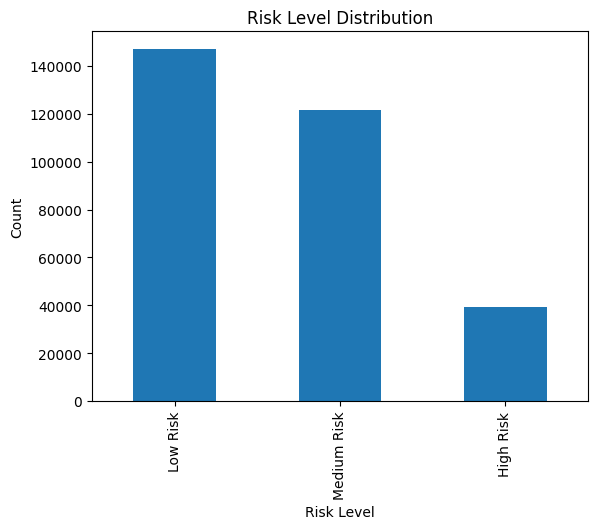

In [28]:
data['risk_label'].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()